[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/Time-Series-Analysis/blob/main/Quantlets/Ch_10/TSA_ch10_seminar/TSA_ch10_seminar.ipynb)

# Time Series Analysis — Seminar 10: State space models, Kalman filter and Markov switching

*Seminar notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- The seminar comes before Lecture 10; the slides give the definitions ("What you need today").
- [Solved] tasks: full solution here and in the slides; [Proposed] tasks: write your own code in the empty cell.
- The seminar is for practice and is not graded; the solutions of [Proposed] tasks are discussed in class.
- The first code cell installs the `arch` package if it is missing.

> Quantlet `TSA_ch10_seminar`: student version of the Seminar 10 notebook. Solved exercises (A1, A3, A5, B1, B3) are shown with code and output; the proposed exercises (A2, A4, A6, B2, B4, C1, C2) are not solved here (an empty code cell where they need code).

> The solutions are discussed in the seminar.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [ ]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/TSA/Chapter_10'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


In [ ]:
# The arch package (GARCH estimation) is not preinstalled in Google Colab: pip install arch
import importlib.util, subprocess, sys
if importlib.util.find_spec('arch') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'arch'])

In [ ]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [ ]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import tsa_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the TSA repository; EUR/RON is the official BNR reference rate.
- Macroeconomic series: FRED (St. Louis Fed), Eurostat and the classic data sets of statsmodels.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [ ]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/Time-Series-Analysis/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the TSA repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years


def read_fred(ids, start=None, end=None):
    """FRED series (St. Louis Fed) from the public fredgraph CSV, e.g. read_fred('UNRATE') or
    read_fred(['GDPC1', 'CPIAUCSL']). Returns a Series (one id) or a DataFrame (several ids)."""
    one = isinstance(ids, str)
    ids = [ids] if one else list(ids)
    out = []
    for sid in ids:
        key = ('fred', sid)
        if key not in _CACHE:
            url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={sid}'
            t = pd.read_csv(url, index_col=0, parse_dates=True, na_values='.')
            _CACHE[key] = pd.to_numeric(t.iloc[:, 0], errors='coerce').rename(sid)
        out.append(_CACHE[key])
    df = pd.concat(out, axis=1).loc[start:end]
    df.index.name = 'date'
    return df.iloc[:, 0].dropna() if one else df


def _eurostat_period(p):
    p = str(p)
    if '-Q' in p:
        y, q = p.split('-Q')
        return pd.Timestamp(int(y), 3 * int(q) - 2, 1)
    if '-' in p and len(p) == 7:
        return pd.Timestamp(p + '-01')
    if len(p) == 4:
        return pd.Timestamp(int(p), 1, 1)
    return pd.Timestamp(p)


def read_eurostat(dataset, key, start=None):
    """One Eurostat series from the public SDMX 2.1 API (SDMX-CSV), e.g. Romanian quarterly real GDP,
    seasonally and calendar adjusted, chain-linked volumes (2010) in million EUR:
        read_eurostat('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
    `key` is the dot-separated series key of the dataset (dimensions in the order of the dataset)."""
    url = (f'https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/{dataset}/{key}?format=SDMX-CSV'
           + (f'&startPeriod={start}' if start else ''))
    ck = ('eurostat', url)
    if ck not in _CACHE:
        t = pd.read_csv(url)
        s = pd.Series(pd.to_numeric(t['OBS_VALUE'], errors='coerce').values,
                      index=[_eurostat_period(p) for p in t['TIME_PERIOD']], name=f'{dataset}:{key}')
        s.index.name = 'date'
        _CACHE[ck] = s.sort_index().dropna()
    return _CACHE[ck]


def load_statsmodels(name):
    """Classic data sets shipped with statsmodels (offline): 'sunspots' (yearly, 1700-2008), 'co2' (weekly,
    Mauna Loa, 1958-2001), 'macrodata' (US quarterly macro, 1959-2009), 'nile' (yearly Nile flow, 1871-1970)."""
    import statsmodels.api as sm
    if name == 'sunspots':
        d = sm.datasets.sunspots.load_pandas().data
        s = d.set_index(pd.to_datetime(d['YEAR'].astype(int).astype(str)))['SUNACTIVITY']
        s.index.name = 'date'
        return s.rename('sunspots')
    if name == 'co2':
        return sm.datasets.co2.load_pandas().data['co2'].rename('co2')
    if name == 'macrodata':
        d = sm.datasets.macrodata.load_pandas().data
        d.index = pd.period_range('1959Q1', periods=len(d), freq='Q').to_timestamp()
        d.index.name = 'date'
        return d
    if name == 'nile':
        d = sm.datasets.nile.load_pandas().data
        s = d.set_index(pd.to_datetime(d['year'].astype(int).astype(str)))['volume']
        s.index.name = 'date'
        return s.rename('nile')
    raise KeyError(f'unknown statsmodels data set: {name}')

## Seminar functions

- Helpers of Chapter 10 (`kalman_filter`, `local_level_ml`, `steady_state`, `uc_fit`, `hp`, `hamilton_filter`, `ms_fit`, `ms_summary`, `concordance`) and the seminar functions: `kalman_by_hand`, `ses_equivalence`, `state_space_forecasts`, `durations`, `hamilton_step`, `b1_inflation_level`, `b3_ip_regimes`.

In [ ]:
import statsmodels.api as sm
SEED = 2026
GDP_RO = ('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
HP_LAMBDA = 1600
HAM_H, HAM_P = 8, 4
DIFFUSE = 10000000.0
NILE_GAPS = [(1891, 1910), (1931, 1950)]
HAMILTON_SAMPLE = ('1951-04-01', '1984-10-01')
MS_SAMPLE = ('1947-04-01', '2019-10-01')
COINCIDENT = ['INDPRO', 'PAYEMS', 'W875RX1', 'CMRMTSPL']
COINC_NAMES = {'INDPRO': 'industrial production', 'PAYEMS': 'payroll employment', 'W875RX1': 'real income less transfers', 'CMRMTSPL': 'real manufacturing and trade sales'}
TVP_PAIR = ('bet', 'stoxx50')
TVP_START = '2005-01-01'
ROLL = 52
SEARCH = 20
SHADE = st.Amber
HICP = ('prc_hicp_minr', 'M.I15.TOTAL.RO')
INFL_START = '2005-01-01'
IP_SAMPLE = ('1960-01-01', '2019-12-01')


def nile():
    """Annual flow of the Nile at Aswan, 1871-1970, 10^8 cubic metres (statsmodels data set)."""
    s = load_statsmodels('nile')
    s.index = s.index.year
    return s.astype(float)


def ro_gdp():
    """Log Romanian real GDP x 100 (quarterly, seasonally and calendar adjusted, Eurostat namq_10_gdp)."""
    x = read_eurostat(*GDP_RO)
    return (100 * np.log(x)).rename('ro_gdp')


def us_gdp_growth():
    """US real GDP growth, quarter on quarter, 100 ln(GDP_t / GDP_{t-1}), in % (FRED GDPC1)."""
    g = read_fred('GDPC1').dropna()
    return (100 * np.log(g).diff()).dropna().rename('us_gdp')


def nber(freq='QS'):
    """NBER recession indicator (FRED USREC): 1 if any month of the period is in a recession."""
    r = read_fred('USREC').dropna()
    return r.resample(freq).max() if freq != 'MS' else r


def weekly_returns(name, start='2000-01-01'):
    """Weekly log returns in % (Friday closes, or the last trading day of the week)."""
    p = load_close(name, start)
    w = p.resample('W-FRI').last().dropna()
    return (100 * np.log(w).diff()).dropna().rename(name)


def save(name, save_it=True):
    if save_it:
        st.check_no_grey(plt.gcf())
        st.save_fig(name)
    else:
        plt.show()


def shade(ax, rec, label='NBER recessions'):
    """Shade the periods with rec == 1 (a 0/1 series with a DatetimeIndex)."""
    rec = rec.fillna(0).astype(int)
    on, first = None, True
    idx = rec.index
    step = idx[1] - idx[0] if len(idx) > 1 else pd.Timedelta(days=90)
    for t, v in rec.items():
        if v and on is None:
            on = t
        if not v and on is not None:
            ax.axvspan(on, t, color=SHADE, alpha=0.28, lw=0, label=label if first else '_')
            on, first = None, False
    if on is not None:
        ax.axvspan(on, idx[-1] + step, color=SHADE, alpha=0.28, lw=0, label=label if first else '_')


def kalman_filter(y, Z, T, H, Q, a1, P1, d=0):
    """Kalman filter for  y_t = Z_t a_t + eps_t, eps_t ~ N(0, H);  a_{t+1} = T a_t + eta_t, eta_t ~ N(0, Q).
    Z: (m,) or (n, m) for a time-varying Z_t; missing y_t (NaN) are skipped in the update step.
    Returns predicted a_t|t-1, P_t|t-1, filtered a_t|t, P_t|t, innovations v_t, their variances F_t, the gains
    K_t = P_t|t-1 Z_t' / F_t and the log-likelihood of the prediction-error decomposition (first d observations
    excluded: the diffuse part)."""
    y = np.asarray(y, float)
    n, m = len(y), len(np.atleast_1d(a1))
    Z = np.asarray(Z, float)
    Zt = np.tile(Z, (n, 1)) if Z.ndim == 1 else Z
    T, Q = np.atleast_2d(T).astype(float), np.atleast_2d(Q).astype(float)
    a, P = np.atleast_1d(a1).astype(float).copy(), np.atleast_2d(P1).astype(float).copy()
    ap, Pp, af, Pf = np.zeros((n, m)), np.zeros((n, m, m)), np.zeros((n, m)), np.zeros((n, m, m))
    v, F, K = np.full(n, np.nan), np.full(n, np.nan), np.zeros((n, m))
    ll, nobs = 0.0, 0
    for t in range(n):
        ap[t], Pp[t] = a, P
        z = Zt[t]
        if np.isnan(y[t]):
            af[t], Pf[t] = a, P                                  # no observation: no update
        else:
            v[t] = y[t] - z @ a
            F[t] = z @ P @ z + H
            K[t] = P @ z / F[t]
            af[t] = a + K[t] * v[t]
            Pf[t] = P - np.outer(K[t], z @ P)
            if t >= d:
                ll += -0.5 * (np.log(2 * np.pi) + np.log(F[t]) + v[t] ** 2 / F[t])
                nobs += 1
        a = T @ af[t]                                            # prediction step
        P = T @ Pf[t] @ T.T + Q
    return {'a_pred': ap, 'P_pred': Pp, 'a_filt': af, 'P_filt': Pf, 'v': v, 'F': F, 'K': K, 'loglik': ll,
            'nobs': nobs, 'a_next': a, 'P_next': P, 'Z': Zt, 'T': T, 'H': H, 'Q': Q}


def rts_smoother(kf):
    """Rauch-Tung-Striebel (1965) smoother: a_t|n = a_t|t + J_t (a_t+1|n - a_t+1|t), J_t = P_t|t T' P_t+1|t^-1,
    P_t|n = P_t|t + J_t (P_t+1|n - P_t+1|t) J_t'."""
    af, Pf, ap, Pp, T = kf['a_filt'], kf['P_filt'], kf['a_pred'], kf['P_pred'], kf['T']
    n = len(af)
    a_s, P_s = af.copy(), Pf.copy()
    for t in range(n - 2, -1, -1):
        J = Pf[t] @ T.T @ np.linalg.inv(Pp[t + 1])
        a_s[t] = af[t] + J @ (a_s[t + 1] - ap[t + 1])
        P_s[t] = Pf[t] + J @ (P_s[t + 1] - Pp[t + 1]) @ J.T
    return a_s, P_s


def disturbance_smoother(kf):
    """Smoothed disturbances (Durbin and Koopman 2012, Sec. 2.5 and 4.5) for a univariate observation: backward
    recursions r_t-1 = Z' v_t / F_t + L_t' r_t, N_t-1 = Z' Z / F_t + L_t' N_t L_t with L_t = T - T K_t Z_t.
    Returns the standardised observation residuals u_t / sqrt(D_t) and state residuals r_t / sqrt(diag N_t)
    (the auxiliary residuals used to detect outliers and level breaks)."""
    Zt, T, v, F, K = kf['Z'], kf['T'], kf['v'], kf['F'], kf['K']
    n, m = Zt.shape
    r, N = np.zeros(m), np.zeros((m, m))
    obs_std, state_std = np.full(n, np.nan), np.full((n, m), np.nan)
    for t in range(n - 1, -1, -1):
        with np.errstate(invalid='ignore', divide='ignore'):
            state_std[t] = r / np.sqrt(np.diag(N))               # r_t and N_t refer to eta_t (between t and t+1)
        z = Zt[t]
        if np.isnan(v[t]):
            r, N = T.T @ r, T.T @ N @ T
            continue
        Kt = T @ K[t]                                            # gain of a_t+1|t
        L = T - np.outer(Kt, z)
        u = v[t] / F[t] - Kt @ r
        D = 1 / F[t] + Kt @ N @ Kt
        obs_std[t] = u / np.sqrt(D)
        r = z * v[t] / F[t] + L.T @ r
        N = np.outer(z, z) / F[t] + L.T @ N @ L
    return obs_std, state_std


def local_level_filter(y, s2_eps, s2_eta, a1=0.0, P1=DIFFUSE):
    """Local level (random walk plus noise): y_t = mu_t + eps_t, mu_t+1 = mu_t + eta_t."""
    return kalman_filter(y, [1.0], [[1.0]], s2_eps, [[s2_eta]], [a1], [[P1]], d=1)


def local_level_ml(y):
    """Maximum likelihood of (sigma2_eps, sigma2_eta) by the prediction-error decomposition (diffuse start)."""
    y = np.asarray(y, float)
    v0 = np.nanvar(np.diff(y[~np.isnan(y)]))
    f = lambda th: -local_level_filter(y, np.exp(th[0]), np.exp(th[1]))['loglik']
    best = min((optimize.minimize(f, x0, method='Nelder-Mead', options={'xatol': 1e-8, 'fatol': 1e-8, 'maxiter': 4000})
                for x0 in ([np.log(v0 / 2), np.log(v0 / 20)], [np.log(v0 / 20), np.log(v0 / 2)])), key=lambda o: o.fun)
    s2e, s2n = np.exp(best.x)
    kf = local_level_filter(y, s2e, s2n)
    n_par, n_obs = 2, kf['nobs']
    return {'s2_eps': float(s2e), 's2_eta': float(s2n), 'q': float(s2n / s2e), 'loglik': float(kf['loglik']),
            'aic': float(-2 * kf['loglik'] + 2 * n_par), 'bic': float(-2 * kf['loglik'] + np.log(n_obs) * n_par), 'kf': kf}


def steady_state(q):
    """Steady state of the local level filter with signal-to-noise ratio q = sigma2_eta / sigma2_eps:
    predicted variance P = sigma2_eps (q + sqrt(q^2 + 4q)) / 2 and gain K = P / (P + sigma2_eps)."""
    p = (q + np.sqrt(q ** 2 + 4 * q)) / 2
    return {'P': float(p), 'K': float(p / (p + 1)), 'Pf': float(p / (p + 1))}


def q_from_alpha(alpha):
    """Signal-to-noise ratio of the local level model whose steady-state gain is the SES weight alpha:
    q = alpha^2 / (1 - alpha) (Muth 1960)."""
    return alpha ** 2 / (1 - alpha)


def profile_loglik(y, q):
    """Log-likelihood with sigma2_eps concentrated out, for a given q (filter with sigma2_eps = 1, sigma2_eta = q)."""
    kf = local_level_filter(y, 1.0, q)
    ok = ~np.isnan(kf['v'])
    ok[0] = False
    v, F = kf['v'][ok], kf['F'][ok]
    n = ok.sum()
    s2 = np.mean(v ** 2 / F)
    return float(-0.5 * n * (np.log(2 * np.pi) + 1 + np.log(s2)) - 0.5 * np.log(F).sum()), float(s2)


def ses_path(y, alpha, l0):
    """Simple exponential smoothing (Chapter 0): l_t = alpha y_t + (1 - alpha) l_t-1; the forecast of y_t+1 is l_t."""
    l, out = l0, []
    for x in y:
        out.append(l)
        l = alpha * x + (1 - alpha) * l
    return np.array(out)


def worked_example(y=(12.0, 11.0, 14.0), a1=10.0, P1=4.0, s2_eps=4.0, s2_eta=1.0):
    """The three-period local level example of the slides, step by step."""
    rows, a, P = [], a1, P1
    for t, yt in enumerate(y, 1):
        F = P + s2_eps
        K = P / F
        v = yt - a
        af, Pf = a + K * v, P * (1 - K)
        rows.append({'t': t, 'y': yt, 'a': a, 'P': P, 'F': F, 'K': K, 'v': v, 'af': af, 'Pf': Pf})
        a, P = af, Pf + s2_eta
    ss = steady_state(s2_eta / s2_eps)
    return {'rows': rows, 'a_next': a, 'P_next': P, 'ss_P': ss['P'] * s2_eps, 'ss_K': ss['K'], 'q': s2_eta / s2_eps}


def uc_fit(y):
    """Unobserved components: smooth trend (integrated random walk) plus a stationary AR(2) cycle (statsmodels)."""
    mod = sm.tsa.UnobservedComponents(np.asarray(y, float), level='smooth trend', autoregressive=2)
    r = mod.fit(method='nm', disp=False, maxiter=5000)
    r = mod.fit(r.params, disp=False, maxiter=1000)
    return r


def hp(y, lam=HP_LAMBDA):
    cyc, tr = sm.tsa.filters.hpfilter(np.asarray(y, float), lam)
    return np.asarray(cyc), np.asarray(tr)


def hamilton_filter(y, h=HAM_H, p=HAM_P):
    """Hamilton (2018): OLS of y_t+h on a constant and y_t, ..., y_t-p+1; the residual is the cyclical component."""
    y = pd.Series(np.asarray(y, float))
    X = pd.concat([y.shift(h + j) for j in range(p)], axis=1)
    X.columns = [f'lag{h + j}' for j in range(p)]
    r = sm.OLS(y, sm.add_constant(X), missing='drop').fit()
    cyc = pd.Series(np.nan, index=y.index)
    cyc.loc[r.resid.index] = r.resid
    return cyc.values, r


def hp_realtime(y, lam=HP_LAMBDA, start=40):
    """One-sided (real-time) HP gap: the last value of the HP gap computed with the data available at each date."""
    y = np.asarray(y, float)
    out = np.full(len(y), np.nan)
    for t in range(start, len(y) + 1):
        out[t - 1] = hp(y[:t], lam)[0][-1]
    return out


def ms_fit(model, seed=SEED, reps=SEARCH):
    np.random.seed(seed)
    return model.fit(search_reps=reps, disp=False)


def regime_order(r, key='const'):
    """Index of the regimes sorted by a parameter (e.g. the mean: recession first)."""
    names = r.model.param_names
    vals = [r.params[names.index(f'{key}[{k}]')] for k in range(r.model.k_regimes)]
    return list(np.argsort(vals))


def ms_summary(r, idx, low):
    """Parameters, transition probabilities, expected durations and ergodic probabilities of a two-regime fit,
    with regime `low` reported as regime 1 (recession / turbulent)."""
    P = r.regime_transition[:, :, 0]                      # P[i, j] = Pr(S_t = i | S_t-1 = j)
    high = 1 - low
    p11, p22 = float(P[low, low]), float(P[high, high])
    erg = (1 - p22) / (2 - p11 - p22)
    names = r.model.param_names
    out = {'p11': p11, 'p22': p22, 'dur1': 1 / (1 - p11), 'dur2': 1 / (1 - p22), 'ergodic1': float(erg),
           'loglik': float(r.llf), 'aic': float(r.aic), 'bic': float(r.bic), 'n': int(len(idx))}
    for nm, v in zip(names, r.params):
        if '[' in nm and not nm.startswith('p['):
            base, k = nm.split('[')
            k = int(k[:-1])
            out[f'{base}_{1 if k == low else 2}'] = float(v)
        elif not nm.startswith('p['):
            out[nm.replace('.', '_')] = float(v)
    return out


def concordance(prob, rec):
    """Share of periods where 'probability > 0.5' agrees with the NBER indicator; and the hits in NBER recessions."""
    prob, rec = pd.Series(prob), pd.Series(rec).reindex(prob.index).fillna(0)
    cls = (prob > 0.5).astype(int)
    return {'concord': float((cls == rec).mean()), 'hit': float(cls[rec == 1].mean()), 'false': float(cls[rec == 0].mean())}


def tvp_filter(y, x, s2_eps, s2_beta, P1=1e4):
    """Regression with a constant intercept and a random-walk slope: y_t = alpha + beta_t x_t + eps_t,
    beta_t+1 = beta_t + eta_t; state (alpha, beta_t), Z_t = (1, x_t)."""
    Z = np.column_stack([np.ones(len(x)), x])
    return kalman_filter(y, Z, np.eye(2), s2_eps, np.diag([0.0, s2_beta]), [0.0, 0.0], P1 * np.eye(2), d=2)


def tvp_data():
    a, b = TVP_PAIR
    r = pd.concat([weekly_returns(a, TVP_START), weekly_returns(b, TVP_START)], axis=1).dropna()
    return r


def coincident():
    """Monthly growth rates (100 x log difference) of the four US coincident indicators, standardised on 1967-2019."""
    X = read_fred(COINCIDENT)
    g = (100 * np.log(X).diff()).dropna()
    mu, sd = g.loc[:'2019'].mean(), g.loc[:'2019'].std()
    return (g - mu) / sd


def ms_vol(name='sp500', k=2):
    x = weekly_returns(name)
    r = ms_fit(sm.tsa.MarkovRegression(x.values, k_regimes=k, switching_variance=True))
    return x, r


def local_whittle(x, m=None):
    """Local Whittle estimator of d (Robinson 1995, Chapter 8), bandwidth m = [T^0.65]."""
    x = np.asarray(x, float)
    T = len(x)
    I = np.abs(np.fft.fft(x - x.mean())) ** 2 / (2 * np.pi * T)
    j = np.arange(1, T // 2 + 1)
    lam, I = 2 * np.pi * j / T, I[1:T // 2 + 1]
    m = m or int(np.floor(T ** 0.65))
    lam, I = lam[:m], I[:m]
    R = lambda d: np.log(np.mean(lam ** (2 * d) * I)) - 2 * d * np.mean(np.log(lam))
    return float(optimize.minimize_scalar(R, bounds=(-0.49, 1.49), method='bounded').x)


def simulate_ms(n, mu, sig2, P, rng, s0=0):
    """Simulate a Markov-switching mean and variance with transition matrix P[i, j] = Pr(S_t = i | S_t-1 = j)."""
    s, out, states = s0, np.empty(n), np.empty(n, int)
    for t in range(n):
        s = rng.choice(len(mu), p=P[:, s])
        states[t] = s
        out[t] = mu[s] + np.sqrt(sig2[s]) * rng.standard_normal()
    return out, states


def kalman_by_hand(y, a1, P1, s2_eps, s2_eta):
    """Local level filter step by step; y may contain None (missing): then a_t|t = a_t, P_t|t = P_t."""
    rows, a, P = [], a1, P1
    for t, yt in enumerate(y, 1):
        if yt is None:
            rows.append({'t': t, 'y': None, 'a': a, 'P': P, 'F': None, 'K': None, 'v': None, 'af': a, 'Pf': P})
            a, P = a, P + s2_eta
            continue
        F = P + s2_eps
        K = P / F
        v = yt - a
        af, Pf = a + K * v, P * (1 - K)
        rows.append({'t': t, 'y': yt, 'a': a, 'P': P, 'F': F, 'K': K, 'v': v, 'af': af, 'Pf': Pf})
        a, P = af, Pf + s2_eta
    q = s2_eta / s2_eps
    ss = steady_state(q)
    return {'rows': rows, 'a_next': a, 'P_next': P, 'q': q, 'ss_P': ss['P'] * s2_eps, 'ss_K': ss['K']}


def ses_equivalence(q_list=(1.0, 0.25), alpha_list=(0.3, 0.5)):
    """Steady-state gain K(q) (= the SES weight alpha) and the inverse map q(alpha) = alpha^2 / (1 - alpha)."""
    return {'K': {str(q): steady_state(q) for q in q_list}, 'q': {str(a): float(q_from_alpha(a)) for a in alpha_list}}


def state_space_forecasts(phi=(0.5, 0.3), yT=(2.0, 1.0), mu_beta=(100.0, 2.0), H=3):
    """Forecasts by iterating the transition equation: AR(2) with state (y_T, y_T-1) and the local linear trend
    with state (mu_T, beta_T)."""
    T = np.array([[phi[0], phi[1]], [1.0, 0.0]])
    a = np.array(yT, float)
    ar = []
    for _ in range(H):
        a = T @ a
        ar.append(float(a[0]))
    Tl = np.array([[1.0, 1.0], [0.0, 1.0]])
    b = np.array(mu_beta, float)
    llt = []
    for _ in range(H):
        b = Tl @ b
        llt.append(float(b[0]))
    return {'ar': ar, 'llt': llt}


def durations(p11, p22):
    """Expected durations 1 / (1 - p_ii), ergodic probabilities and two-step transition probabilities."""
    P = np.array([[p11, 1 - p22], [1 - p11, p22]])         # P[i, j] = Pr(S_t = i | S_t-1 = j)
    P2 = P @ P
    pi1 = (1 - p22) / (2 - p11 - p22)
    return {'d1': 1 / (1 - p11), 'd2': 1 / (1 - p22), 'pi1': float(pi1), 'pi2': float(1 - pi1),
            'p11_2': float(P2[0, 0]), 'p22_2': float(P2[1, 1]), 'p21_2': float(P2[1, 0])}


def hamilton_step(prob1_prev, p11, p22, y, mu1, mu2, sigma):
    """One step of the Hamilton filter: prediction Pr(S_t = 1 | t-1), densities, update Pr(S_t = 1 | t),
    likelihood contribution."""
    pred1 = p11 * prob1_prev + (1 - p22) * (1 - prob1_prev)
    f1, f2 = stats.norm.pdf(y, mu1, sigma), stats.norm.pdf(y, mu2, sigma)
    lik = pred1 * f1 + (1 - pred1) * f2
    filt1 = pred1 * f1 / lik
    return {'pred1': float(pred1), 'f1': float(f1), 'f2': float(f2), 'lik': float(lik), 'loglik': float(np.log(lik)),
            'filt1': float(filt1), 'next_pred1': float(p11 * filt1 + (1 - p22) * (1 - filt1))}


def ro_monthly_inflation(start=INFL_START):
    """Romanian monthly inflation 100 ln(P_t / P_t-1), seasonally adjusted with the monthly means (plus the mean)."""
    x = (100 * np.log(read_eurostat(*HICP)).diff()).dropna().loc[start:]
    return (x - x.groupby(x.index.month).transform('mean') + x.mean()).rename('infl')


def b1_inflation_level(save_it=True):
    """Local level model of Romanian monthly inflation (SA): ML variances, steady-state gain and SES, filtered and
    smoothed underlying inflation (annualised x 12)."""
    x = ro_monthly_inflation()
    ml = local_level_ml(x.values)
    kf = ml['kf']
    a_s, P_s = rts_smoother(kf)
    af = kf['a_filt'][:, 0]
    ss = steady_state(ml['q'])
    ses = sm.tsa.SimpleExpSmoothing(x.values, initialization_method='estimated').fit()
    sm_ = pd.Series(a_s[:, 0], index=x.index)
    fig, ax = plt.subplots(figsize=(10, 3.8))
    ax.plot(x.index, 12 * x.values, color=st.MainBlue, lw=0.7, label='monthly inflation x 12 (SA), %')
    ax.plot(x.index[1:], 12 * af[1:], color=st.Orange, lw=1.3, label='filtered level x 12')
    ax.plot(x.index, 12 * sm_.values, color=st.IDAred, lw=2, label='smoothed level x 12')
    ax.axhline(0, color=st.DarkText, lw=0.6)
    st.legend_outside_bottom(ax, ncol=3, y=-0.12)
    save('ch10_sem_b1', save_it)
    return {'s2_eps': ml['s2_eps'], 's2_eta': ml['s2_eta'], 'q': ml['q'], 'loglik': ml['loglik'], 'K': ss['K'],
            'alpha_ses': float(ses.params['smoothing_level']), 'n': int(len(x)), 'first': str(x.index[0].date()),
            'last': str(x.index[-1].date()), 'peak': float(12 * sm_.max()), 'peak_d': str(sm_.idxmax().date()),
            'low': float(12 * sm_.loc['2010':].min()), 'low_d': str(sm_.loc['2010':].idxmin().date()),
            'last_s': float(12 * sm_.iloc[-1]), 'last_f': float(12 * af[-1]), 'sd_last': float(12 * np.sqrt(P_s[-1, 0, 0])),
            'raw_sd': float(12 * x.std())}


def us_log_gdp():
    g = read_fred('GDPC1').dropna()
    return (100 * np.log(g)).rename('us_gdp')


def b3_ip_regimes(save_it=True):
    """Two-regime Markov switching (mean and variance) for US industrial production growth (monthly, 1960-2019)
    against the NBER recession months."""
    ip = read_fred('INDPRO').dropna()
    x = (100 * np.log(ip).diff()).dropna().loc[IP_SAMPLE[0]:IP_SAMPLE[1]]
    rec = nber('MS')
    r = ms_fit(sm.tsa.MarkovRegression(x.values, k_regimes=2, switching_variance=True))
    low = regime_order(r)[0]
    sp = pd.Series(r.smoothed_marginal_probabilities[:, low], index=x.index)
    fp = pd.Series(r.filtered_marginal_probabilities[:, low], index=x.index)
    fig, ax = plt.subplots(figsize=(10, 3.8))
    shade(ax, rec.reindex(x.index))
    ax.plot(sp.index, sp.values, color=st.IDAred, lw=1.2, label='smoothed Pr(recession regime)')
    ax.set_ylim(-0.02, 1.02)
    st.legend_outside_bottom(ax, ncol=2, y=-0.12)
    save('ch10_sem_b3', save_it)
    s = ms_summary(r, x.index, low)
    s.update({'conc': concordance(sp, rec), 'conc_f': concordance(fp, rec), 'first': str(x.index[0].date()),
              'last': str(x.index[-1].date()), 'n_rec': int((rec.reindex(x.index) == 1).sum()),
              'sd1': float(np.sqrt(s['sigma2_1'])), 'sd2': float(np.sqrt(s['sigma2_2']))})
    return s

# Part A: computations on paper

- Do each computation on paper first; then check it with the code.

## A1 [Solved]: the Kalman filter for three periods

**Context.** Local level with $\sigma^2_\varepsilon = 1$, $\sigma^2_\eta = 1$; $a_1 = 0$, $P_1 = 1$; $y = (1, 3, 2)$.

1. For $t = 1, 2, 3$ compute $F_t$, $K_t$, $v_t$, $a_{t|t}$, $P_{t|t}$ and the next prediction.
2. Give the forecast of $y_4$ and its variance.
3. Compute the steady-state gain for $q = 1$.

**Report:** a table of the three steps, one forecast, $\bar K$.

In [8]:
# Solution
r = kalman_by_hand([1.0, 3.0, 2.0], 0.0, 1.0, 1.0, 1.0)
print(pd.DataFrame(r['rows']).round(3))
print('a4 =', r['a_next'], ' P4 =', round(r['P_next'], 3), ' steady-state K =', round(r['ss_K'], 3))

   t    y    a    P    F      K    v   af     Pf
0  1  1.0  0.0  1.0  2.0  0.500  1.0  0.5  0.500
1  2  3.0  0.5  1.5  2.5  0.600  2.5  2.0  0.600
2  3  2.0  2.0  1.6  2.6  0.615  0.0  2.0  0.615
a4 = 2.0  P4 = 1.615  steady-state K = 0.618


**Interpretation of the result.** The gain rises from 0.5 to 0.615, close to the steady state 0.618; the forecast of $y_4$ is 2 with variance $1.615 + 1$.

## A2 [Proposed]: a missing observation

**Context.** $\sigma^2_\varepsilon = 2$, $\sigma^2_\eta = 0.5$; $a_1 = 5$, $P_1 = 2$; $y = (6, \text{missing}, 4)$. Model: A1.

1. Run the filter for $t = 1, 2, 3$, skipping the update at $t = 2$.
2. Explain why $K_3$ equals $K_1$.
3. Compute $\bar K$ for this $q$ and the equivalent SES weight.

**Report:** the three steps, one sentence, $\bar K$.

In [ ]:
# Your code here


## A3 [Solved]: exponential smoothing is a steady-state Kalman filter

1. Show that $a_{t+1} = a_t + \bar K(y_t - a_t)$ is SES.
2. Compute $\bar K$ for $q = 1$ and $q = 0.25$.
3. An SES model has $\alpha = 0.3$: find $q$.

**Report:** one line of algebra, two gains, one $q$.

In [10]:
# Solution
print(ses_equivalence())
print('q for alpha = 0.3:', round(q_from_alpha(0.3), 4))

{'K': {'1.0': {'P': 1.618033988749895, 'K': 0.6180339887498949, 'Pf': 0.6180339887498949}, '0.25': {'P': 0.6403882032022076, 'K': 0.3903882032022075, 'Pf': 0.3903882032022075}}, 'q': {'0.3': 0.1285714285714286, '0.5': 0.5}}
q for alpha = 0.3: 0.1286


**Interpretation of the result.** $\bar K = 0.618$ for $q = 1$ and $0.390$ for $q = 0.25$; $\alpha = 0.3$ means $q = 0.129$: a level that moves little relative to the noise.

## A4 [Proposed]: state space forms and forecasts

**Context.** AR(2) with $\phi_1 = 0.5$, $\phi_2 = 0.3$; a local linear trend. Model: A1.

1. Write $Z$, $T$, $R$, $Q$, $H$ for the AR(2).
2. From $(y_T, y_{T-1}) = (2, 1)$ forecast $h = 1, 2, 3$.
3. Write $Z$, $T$ of the local linear trend and forecast three steps from $\mu_T = 100$, $\beta_T = 2$.

**Report:** two sets of matrices and six forecasts.

In [ ]:
# Your code here


## A5 [Solved]: durations of recessions and expansions

**Context.** $p_{11} = 0.75$ (recession), $p_{22} = 0.95$ (expansion).

1. Write the transition matrix and compute the expected durations.
2. Compute the ergodic probabilities.
3. From a recession, compute the probability of a recession two quarters later.

**Report:** two durations, two probabilities, one two-step probability.

In [12]:
# Solution
durations(0.75, 0.95)

{'d1': 4.0,
 'd2': 19.999999999999982,
 'pi1': 0.1666666666666668,
 'pi2': 0.8333333333333333,
 'p11_2': 0.575,
 'p22_2': 0.9149999999999999,
 'p21_2': 0.425}

**Interpretation of the result.** Recessions last 4 quarters and expansions 20 on average; one quarter in six is a recession quarter; after two quarters a recession continues with probability 0.575.

## A6 [Proposed]: one step of the Hamilton filter

**Context.** The model of A5 with $\mu_1 = -0.5$, $\mu_2 = 1$, $\sigma = 1$; $\Pr(S_{t-1} = 1 \mid Y_{t-1}) = 0.2$; $y_t = -1$. Model: A5.

1. Compute the predicted probability.
2. Compute the densities and the filtered probability.
3. Give the likelihood contribution and next quarter's predicted probability.

**Report:** four probabilities and one log-density.

In [ ]:
# Your code here


# Part B: real data and interpretation

## B1 [Solved]: underlying Romanian inflation

**Question.** How fast does the underlying level of Romanian inflation move, and which SES weight does the data choose?

1. Fit the local level model by maximum likelihood.
2. Compute $\bar K$ and compare it with the SES weight estimated directly.
3. Plot the filtered and smoothed level ($\times 12$) and report its peak and last value.
4. Interpretation: what does the size of $\hat q$ say about monthly inflation?

**Report:** three variances, two weights, two levels, one sentence.

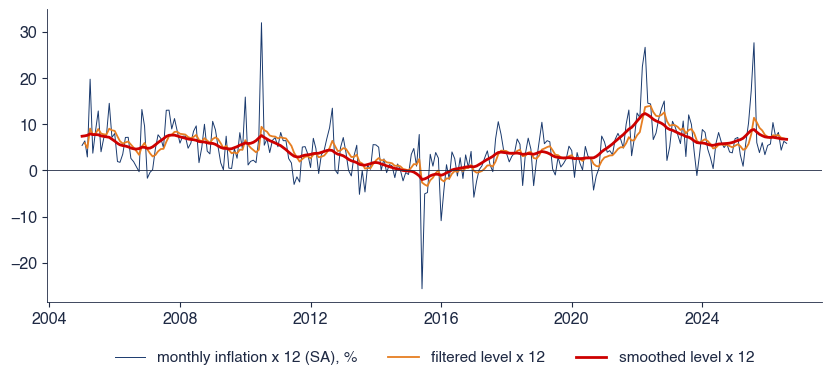

{'s2_eps': 0.1424, 's2_eta': 0.0057, 'q': 0.0399, 'loglik': -141.4976, 'K': 0.1808, 'alpha_ses': 0.1754, 'n': 260, 'first': '2005-01-01', 'last': '2026-08-01', 'peak': 12.3268, 'peak_d': '2022-04-01', 'low': -1.9569, 'low_d': '2015-06-01', 'last_s': 6.7534, 'last_f': 6.7534, 'sd_last': 1.9257, 'raw_sd': 5.5711}


In [14]:
# Solution
b1 = b1_inflation_level(save_it=False)
print({k: (round(v, 4) if isinstance(v, float) else v) for k, v in b1.items()})

**Interpretation of the result.** $q \approx 0.04$: most monthly movements are noise; $\bar K \approx 0.18$, close to the SES weight 0.175; the underlying inflation peaked at about 12% in 2022.

## B2 [Proposed]: the US output gap

**Question.** How close are three statistical output gaps to the CBO gap, and which one would you use in real time? Model: B1.

1. Compute the UC cycle, the HP gap and the Hamilton filter of $100\log$ GDP (`us_log_gdp()`).
2. Compute the CBO gap $100(\mathrm{GDP}/\mathrm{GDPPOT} - 1)$ (FRED GDPPOT) and the correlations, including the filtered UC cycle.
3. Report the standard deviations and the latest values.
4. Interpretation: which measure would you use to judge the economy today?

**Report:** five correlations, four standard deviations, four latest values, one sentence.

In [ ]:
# Your code here


## B3 [Solved]: recessions in US industrial production

**Question.** Does a two-regime model of industrial production find the NBER recessions?

1. Fit a two-regime model with switching mean and variance.
2. Report the regime means and standard deviations, $p_{11}$, $p_{22}$ and the durations.
3. Classify each month by the smoothed and by the filtered probability and compare with the NBER months.
4. Interpretation: does the recession regime match the NBER recessions?

**Report:** six parameters, two durations, two concordance tables, one sentence.

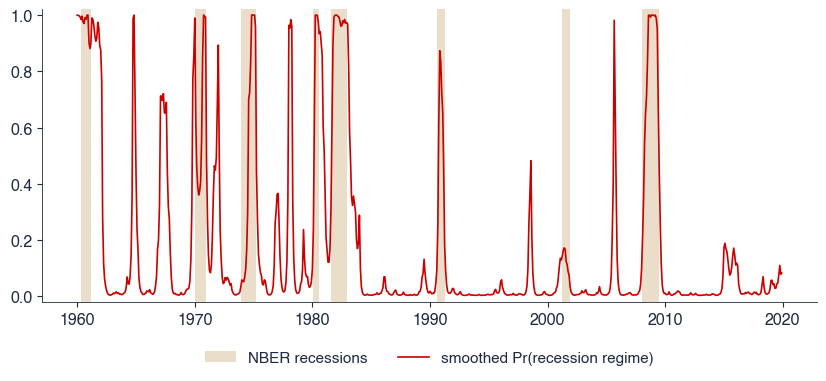

{'p11': 0.8742569838589194, 'p22': 0.969897360318941, 'dur1': 7.952727958092114, 'dur2': 33.21967809451657, 'ergodic1': 0.19315674551374026, 'loglik': -717.458013760722, 'aic': 1446.916027521444, 'bic': 1474.3915347935047, 'n': 720, 'const_2': 0.2872128166111802, 'const_1': -0.16115899516130758, 'sigma2_2': 0.2602649494032891, 'sigma2_1': 1.689429001845705, 'conc': {'concord': 0.8944444444444445, 'hit': 0.6881720430107527, 'false': 0.07496012759170653}, 'conc_f': {'concord': 0.8583333333333333, 'hit': 0.5698924731182796, 'false': 0.09888357256778309}, 'first': '1960-01-01', 'last': '2019-12-01', 'n_rec': 93, 'sd1': 1.299780366771904, 'sd2': 0.5101616894703963}


In [16]:
# Solution
b3 = b3_ip_regimes(save_it=False)
print({k: v for k, v in b3.items()})

**Interpretation of the result.** The recession regime (mean $-0.16\%$, volatile) lasts about 8 months; it finds 69% of the NBER months with 7% false alarms (smoothed), fewer with the filtered probabilities.

## B4 [Proposed]: volatility regimes of the BET

**Question.** Does the Bucharest market have calm and turbulent regimes, and are they those of the S&P 500? Model: B3.

1. Fit a two-regime model with switching mean and variance to weekly BET returns; report the annualised volatilities and durations.
2. List the three years with the largest share of turbulent weeks.
3. Fit a GARCH(1,1) and correlate its volatility with the regime-implied volatility.
4. Interpretation: are the turbulent periods of the BET those of the S&P 500?

**Report:** two volatilities, two durations, three years, two correlations, one sentence.

In [ ]:
# Your code here


# Part C: open questions and AI critique

## C1 [Proposed]: regimes of Romanian inflation

**Question.** How many inflation regimes has Romania had since 1996, and when did the low-inflation regime begin? Model: B3.

1. Fit models with two and three regimes and compare them by BIC.
2. For three regimes, report the means, durations and the date when the low regime becomes permanent.
3. Propose one more check.
4. Interpretation: did inflation targeting start the low-inflation regime?

**Report:** six parameters, a date, a check and a project plan.

In [ ]:
# Your code here


## C2 [Proposed]: audit an AI answer

**Context.** An AI assistant answered:

- (a) for the Nile, q = 0.097, so the SES weight is alpha = q = 0.097;
- (b) the Kalman gain is K = sigma2_eps / (P + sigma2_eps): noisier data get more weight;
- (c) with p11 = 0.75, recessions last p11 / (1 - p11) = 3 quarters on average;
- (d) to call a recession in real time, use `smoothed_marginal_probabilities`;
- (e) the last value of the HP gap is a reliable estimate of today's output gap;
- (f) in the local level model the forecasts of all horizons are equal; only their variance grows.

1. For each statement, say whether it is correct; if not, give the correct statement and the correct number.

**Report:** six verdicts with one line of justification each.

In [ ]:
# Your code here
